# **Mini Project:**
# **Predicting Airline Passenger Satisfaction**
---

# **1.0 Business Understanding**
---
## 1.1 Business Overview
We are trying to analyse the passenger satisfaction in the 


## 1.2 Stakeholder 
- Airline Companies
- Airline Investors
- Airline Staff

## 1.3 Problem Statement 


## 1.4 Objectives 
### 1.4.1 Main Objective 


### 1.4.2 Specific Objectives 


## 1.5 Research Questions 
1. 
   
## 1.6 Success Criteria 


# **2.0 Data Understanding** 
---

### 2.1 Importing the Required Libraries

In [1]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

### 2.2 Loading the Dataset

In [2]:
airline_df = pd.read_csv("dataset.csv")
airline_df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### 2.3 Dataset Overview

In [3]:
# Dataset information 

dataset_info = pd.DataFrame({
    'Metric': ['Passenger Responses', 'Features', 'Missing Values', 'Duplicates'],
    'Value': [
        airline_df.shape[0],
        airline_df.shape[1],
        airline_df.isnull().sum().sum(),
        airline_df.duplicated().sum()
    ]
})
dataset_info

,Metric,Value
0,Passenger Responses,129880
1,Features,24
2,Missing Values,393
3,Duplicates,0


From the summary above:
- The dataset contains 129,880 passenger responses across 24 features.
- The initial data quality assessment shows 393 missing values across the dataset and no duplicate records.

The absence of duplicate rows suggests that each observation represents a unique passenger survey response. However, the presence of missing values indicates that some variables may require preprocessing, such as imputation or removal of the rows, before modelling can be performed. This step will be important to ensure that machine learning models can be trained without bias or loss of information.

In [4]:
# Dataset datatypes 

airline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Ease of Online booking             129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Food and drink                     1298

In [5]:
# Understanding the columns with the missing values

airline_df.isnull().sum().sort_values(ascending = True) 

id                                     0
Departure Delay in Minutes             0
Cleanliness                            0
Inflight service                       0
Checkin service                        0
Baggage handling                       0
Leg room service                       0
On-board service                       0
Inflight entertainment                 0
Seat comfort                           0
Online boarding                        0
Food and drink                         0
Gate location                          0
Ease of Online booking                 0
Departure/Arrival time convenient      0
Inflight wifi service                  0
Flight Distance                        0
Class                                  0
Type of Travel                         0
Age                                    0
Customer Type                          0
Gender                                 0
satisfaction                           0
Arrival Delay in Minutes             393
dtype: int64

In [6]:
# Dropping the rows with the missing values 

airline_df = airline_df.dropna()
airline_df.isnull().sum().sort_values(ascending = True)

id                                   0
Departure Delay in Minutes           0
Cleanliness                          0
Inflight service                     0
Checkin service                      0
Baggage handling                     0
Leg room service                     0
On-board service                     0
Inflight entertainment               0
Seat comfort                         0
Online boarding                      0
Food and drink                       0
Gate location                        0
Ease of Online booking               0
Departure/Arrival time convenient    0
Inflight wifi service                0
Flight Distance                      0
Class                                0
Type of Travel                       0
Age                                  0
Customer Type                        0
Gender                               0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [7]:
# Number of unique values in the dataset per column

airline_df.nunique()

id                                   129487
Gender                                    2
Customer Type                             2
Age                                      75
Type of Travel                            2
Class                                     3
Flight Distance                        3821
Inflight wifi service                     6
Departure/Arrival time convenient         6
Ease of Online booking                    6
Gate location                             6
Food and drink                            6
Online boarding                           6
Seat comfort                              6
Inflight entertainment                    6
On-board service                          6
Leg room service                          6
Baggage handling                          5
Checkin service                           6
Inflight service                          6
Cleanliness                               6
Departure Delay in Minutes              464
Arrival Delay in Minutes        

In [8]:
airline_df = airline_df.drop("id", axis = 'columns')
airline_df.head(2)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied


#### Missing Values Analysis
- An inspection of missing values shows that only one feature, Arrival Delay in Minutes, contains missing responses. Specifically, 393 values are missing out of a total of 129,880, representing approximately 0.3% of the dataset.
- Since the number of missing values is negligible and limited to a single variable, the rows containing missing values were removed. This implifies preprocessing on the overall dataset size.

#### Unique Values, Data Types and Feature Inspection
- The number of unique values for each column was then examined to better understand the structure of the dataset. Several variables, such as Gender, Customer Type, Type of Travel, and Class, contain a small number of unique values, which is consistent with their categorical data type.
- In contrast, variables such as Age, Flight Distance, and the delay variables contain many unique values, which goes hand in hand that they represent continuous or numerical features according to their data type.
- Additionally, many service-related variables; Seat comfort, Inflight entertainment, and Online boarding contain a limited set of integer values, suggesting that they represent ordinal ratings provided by passengers in the survey
  
#### Removing the id Column
- The id column was removed from the dataset since it serves only as a unique identifier for each passenger response and does not contain meaningful information for predicting passenger satisfaction. 

### 2.4 Summary Statistics 

In [9]:
airline_df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,2.728544,3.057349,2.756786,2.976909,3.204685,3.252720,3.441589,3.358067,3.383204,3.351078,3.631886,3.306239,3.642373,3.286222,14.643385,15.091129
std,15.117597,997.560954,1.329235,1.526787,1.401662,1.278506,1.329905,1.350651,1.319168,1.334149,1.287032,1.316132,1.180082,1.266146,1.176614,1.313624,37.932867,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


### Summary Statistics of Numerical Features

- The dataset contains 129,487 observations across all numerical variables, this confirms that missing values have been successfully removed.

#### Passenger Characteristics

- The Age column ranges from 7 to 85 years, with a mean of 39.43 and a median of 40.
- The values of mean and median are quite similar suggesting that the age distribution is relatively balanced without extreme skewness.

#### Flight Characteristics

- The Flight Distance column ranges from 31 to 4983 units, with a mean of 1190.21 and a median of 844.
- The noticeable difference between the mean being greater than the median indicates it's a right-skewed distribution, suggesting that while most flights are relatively short, a smaller number of long-distance flights increase the average distance.

#### Passenger Service Ratings

Several variables represent passenger ratings of service quality, including:

- Inflight wifi service
- Seat comfort
- Online boarding
- Inflight entertainment
- Food and drink
- Cleanliness

These variables have values ranging between 0 and 5, indicating that they are likely ordinal survey ratings. Because these variables share a similar scale, they are already standardised relative to one another and may not require additional scaling during preprocessing.

#### Flight Delay Variables

The Departure Delay in Minutes and Arrival Delay in Minutes columns show a wide range of values:

- Departure Delay: 0 – 1592 minutes
- Arrival Delay: 0 – 1584 minutes

Both variables have a median value of 0, while the maximum values are substantially higher than the upper quartile. For example, the 75th percentile for departure delay is 12 minutes, while the maximum exceeds 1500 minutes.

This suggests the presence of extreme delay values, which may represent unusual flight disruptions. These values indicate potential outliers that will be examined further during exploratory data analysis.

# **3.0 Exploratory Data Analysis**
---

In [10]:
airline_df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### 3.1 Target Variable Distribution

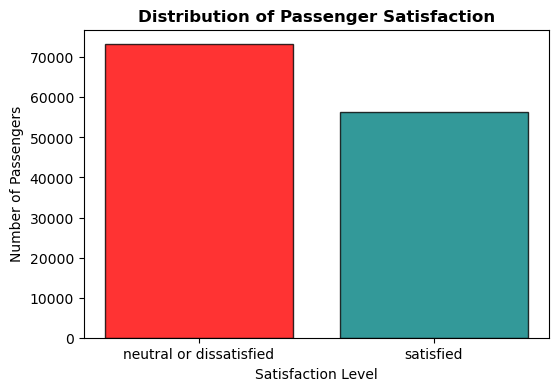

In [11]:
satisfaction_counts = airline_df["satisfaction"].value_counts()
satisfaction_colors = {'satisfied': 'teal', 'neutral or dissatisfied': 'red'}
colours = [satisfaction_colors[satisfaction] for satisfaction in satisfaction_counts.index]

plt.figure(figsize = (6, 4))
bars = plt.bar(satisfaction_counts.index, satisfaction_counts.values, color = colours, edgecolor = 'black', alpha = 0.8)

plt.title('Distribution of Passenger Satisfaction', fontweight = 'bold')
plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Passengers')

plt.show()

- The bar chart above illustrates the distribution of the target variable satisfaction, which consists of two categories: “satisfied” and “neutral or dissatisfied”.
- From the plot, it can be observed that the classes are not evenly distributed, with a larger number of passengers falling into the “neutral or dissatisfied” category compared to those who are “satisfied”.
- The imbalance in the target variable may influence the performance of machine learning models, as algorithms can become biased toward the majority class. To address this issue, techniques such as SMOTE (Synthetic Minority Oversampling Technique) or other resampling methods may be applied during the modelling stage to balance the class distribution.

### 3.2 Numerical Feature Distributions

- From the .describe() summary statistics examined earlier, the continuous numerical variables in the dataset are Age, Flight Distance, Departure Delay in Minutes, and Arrival Delay in Minutes.
- The remaining numerical variables represent ordinal service ratings on a 1–5 scale, which are discrete rather than continuous. Therefore, the distribution analysis will focus on these four continuous variables.

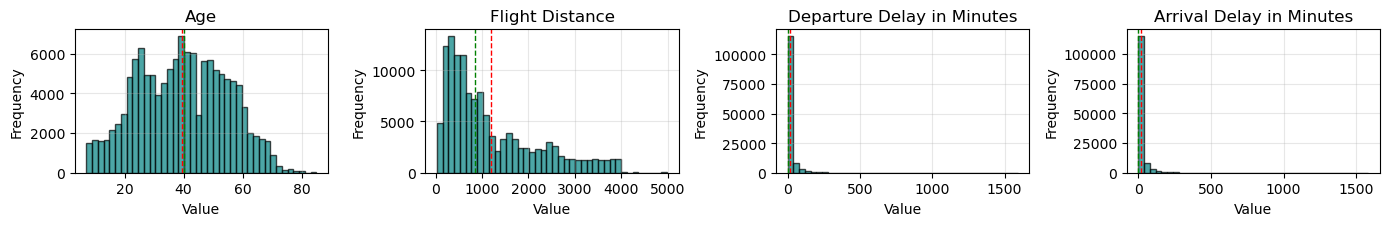

In [12]:
# numerical features only

features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
plt.figure(figsize = (14,10))

for i, feat in enumerate(features):
    plt.subplot(5,4,i+1)

    data = airline_df[feat]

    plt.hist(data, bins=40, color = 'teal', edgecolor = 'black', alpha = 0.7)

    plt.axvline(data.mean(), color = 'red', linestyle = '--', linewidth = 1, label = 'Mean')
    plt.axvline(data.median(), color = 'green', linestyle = '--', linewidth = 1, label = 'Median')

    plt.title(feat)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Patterns shown by the distributions of the continuous numerical variables:
#### Age
- The age distribution appears approximately bell-shaped, with most passengers between averagely above 22 and below 55 years old.
- The mean and median are relatively close, suggesting limited skewness.

#### Flight Distance
- Flight distance is right-skewed, meaning most flights are shorter distances while a smaller number of passengers travel very long distances.
- This is typical for airline datasets where short and medium-haul flights dominate.

#### Departure Delay in Minutes
- The distribution is heavily right-skewed, with most flights having little or no delay.
- However, there are extreme delay values, indicating occasional severe disruptions.

#### Arrival Delay in Minutes
- Similar to departure delay, this variable shows strong right skewness with many observations near zero and some large delays.
- Overall, delay-related variables exhibit significant skewness and extreme values.

### 3.3 Feature vs Target Analysis

#### 3.3.1 Categorical Features vs Satisfaction

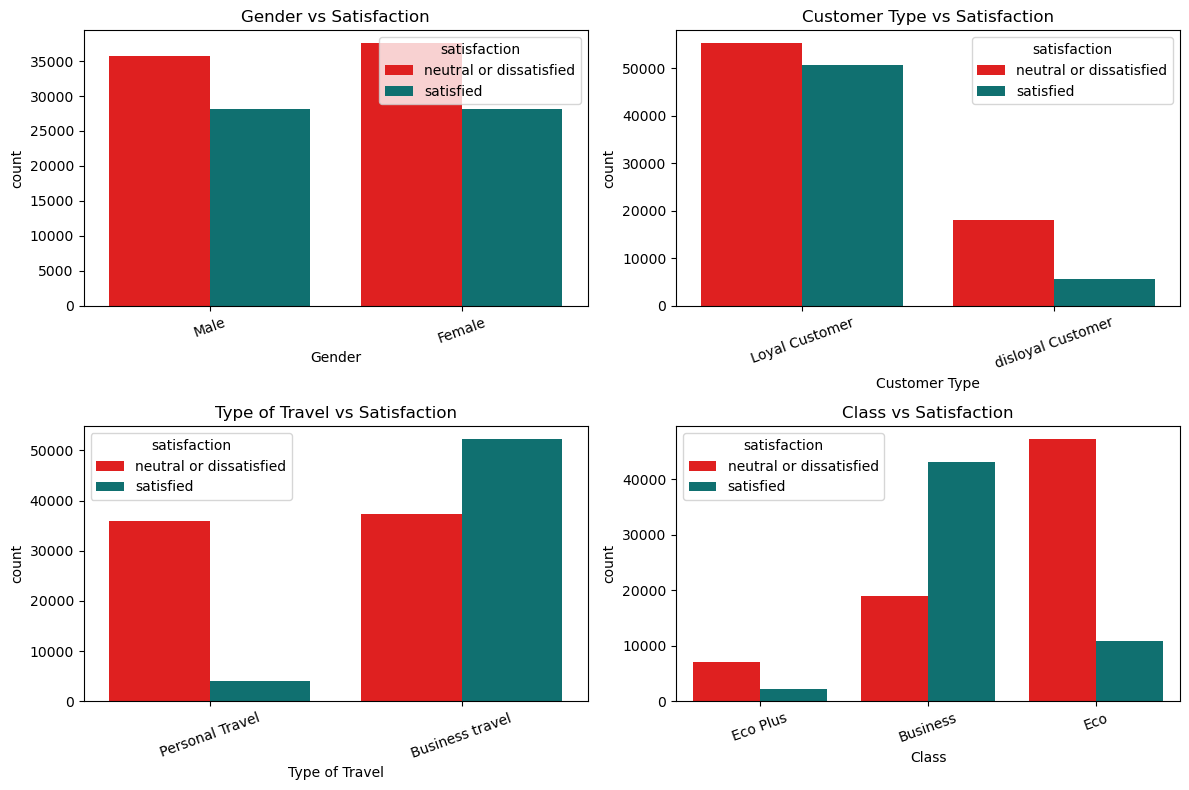

In [13]:
categorical_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

plt.figure(figsize = (12,8))

for i, feat in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(data = airline_df, x = feat, hue = 'satisfaction', palette = satisfaction_colors)
    plt.title(f"{feat} vs Satisfaction")
    plt.xticks(rotation = 20)

plt.tight_layout()
plt.show()

### Patterns shown when comparing categorical variables with passenger satisfaction:

#### Gender
- Satisfaction levels appear relatively balanced between male and female passengers, suggesting gender may not strongly influence satisfaction.

#### Customer Type
- Loyal customers show a higher proportion of satisfied passengers compared to disloyal customers.
- This suggests that customer loyalty may be associated with higher satisfaction levels.

#### Type of Travel
- Business travel shows a higher proportion of satisfied passengers, whereas personal travel has more neutral or dissatisfied responses.

#### Class
Passenger satisfaction varies strongly by class:
- Business class passengers show the highest satisfaction rates
- Economy class passengers show the lowest satisfaction

This indicates that travel class is likely an important predictor of satisfaction.

#### 3.3.2 Service Ratings vs Satisfaction

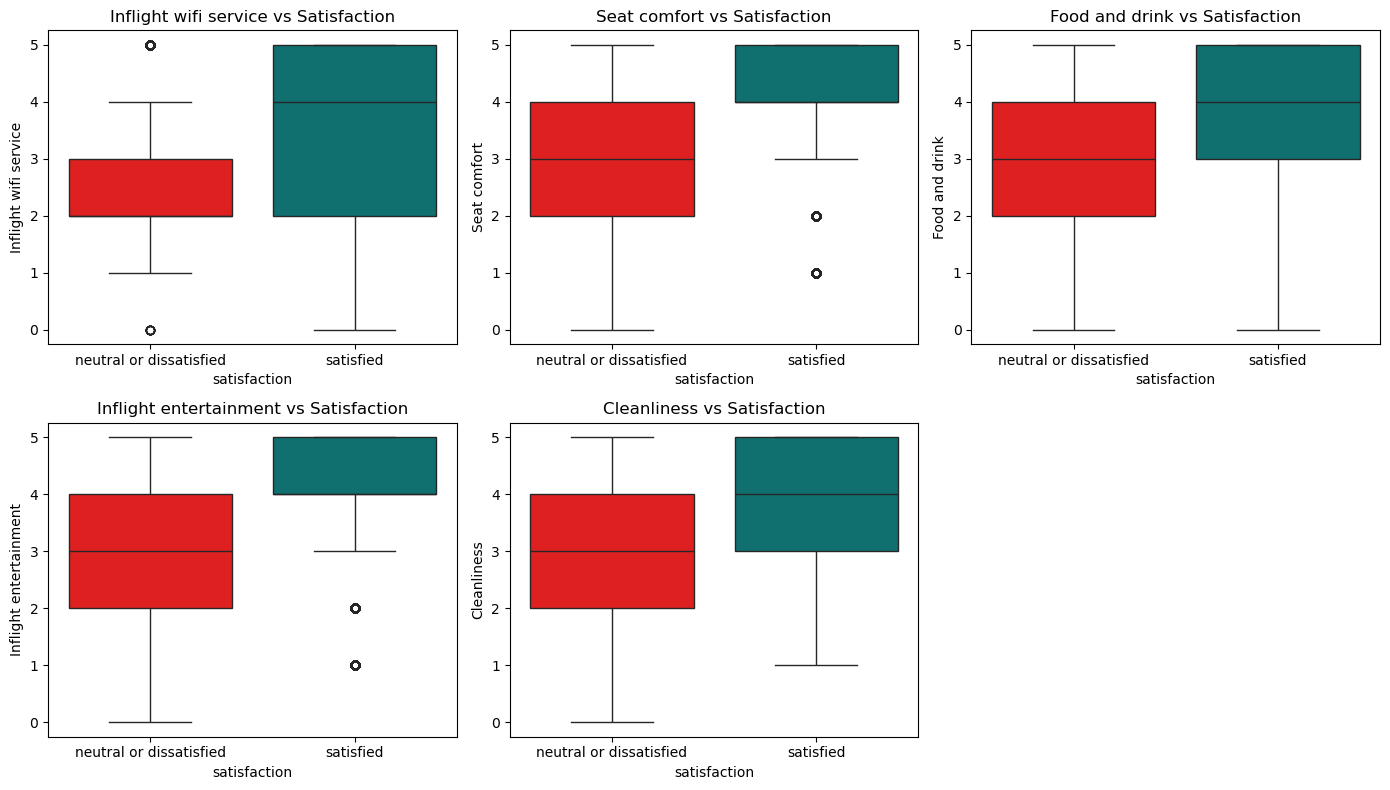

In [14]:
service_features = ['Inflight wifi service', 'Seat comfort', 'Food and drink', 'Inflight entertainment', 'Cleanliness']

plt.figure(figsize = (14,8))

for i, feat in enumerate(service_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data = airline_df, x = 'satisfaction', y = feat, palette = satisfaction_colors)
    plt.title(f"{feat} vs Satisfaction")

plt.tight_layout()
plt.show()

### Patterns shown when comparing service ratings with passenger satisfaction:

Passengers who reported being satisfied consistently have higher service ratings across features such as:
- Inflight wifi service
- Seat comfort
- Food and drink
- Inflight entertainment
- Cleanliness

In contrast, passengers who are neutral or dissatisfied tend to give lower ratings.
This highlights that service quality variables are strongly related to passenger satisfaction, making them possibly important predictors for the classification model.

#### 3.3.3 Continuous Variabales vs Satisfaction

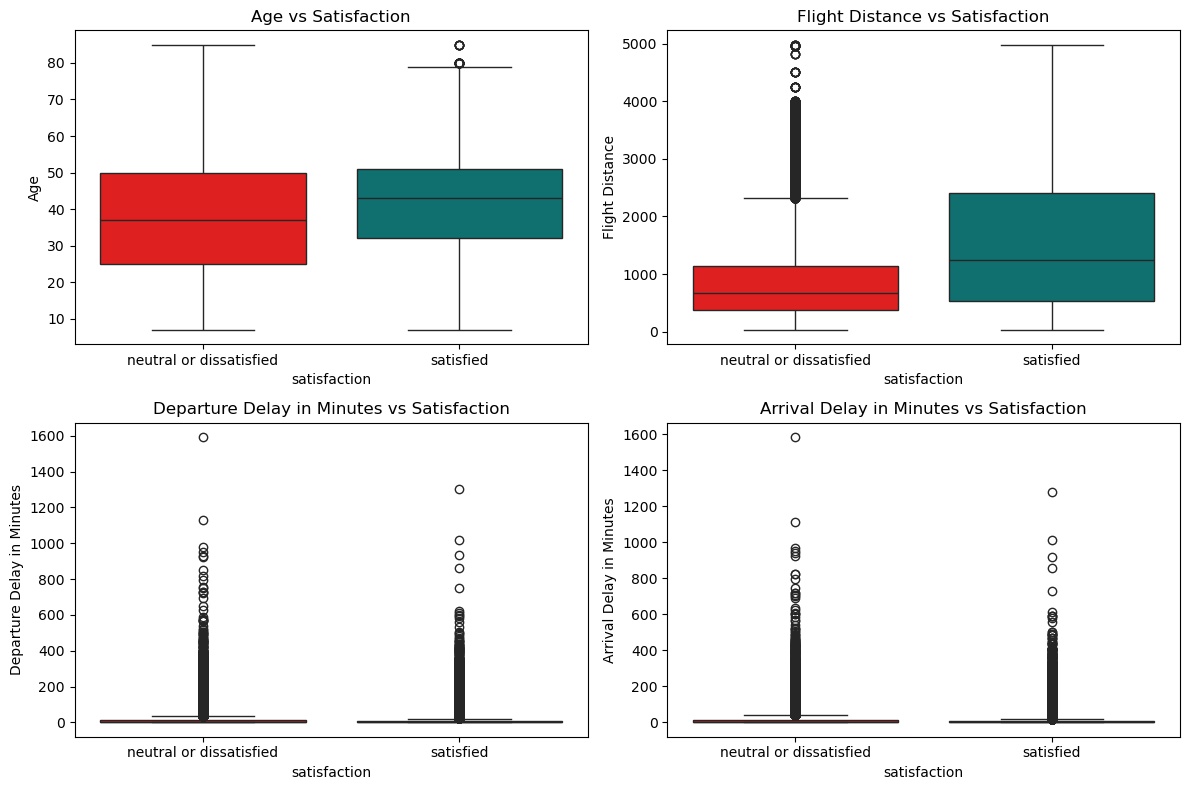

In [15]:
continuous_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize = (12,8))

for i, feat in enumerate(continuous_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data = airline_df, x = 'satisfaction', y = feat,  palette = satisfaction_colors)
    plt.title(f"{feat} vs Satisfaction")

plt.tight_layout()
plt.show()

### Patterns shown when comparing continuous variables with passenger satisfaction:

#### Age
- The age distribution appears similar across satisfaction groups, suggesting age may not be a strong predictor of satisfaction.

#### Flight Distance
- Satisfied passengers tend to appear slightly more frequently on longer flights, though the difference is not very pronounced.

#### Departure Delay
- Passengers experiencing larger delays are more likely to be neutral or dissatisfied.

#### Arrival Delay
- Similar to departure delays, higher arrival delays are associated with lower passenger satisfaction.

These results indicate that delay-related variables may negatively impact satisfaction

### 3.4 Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

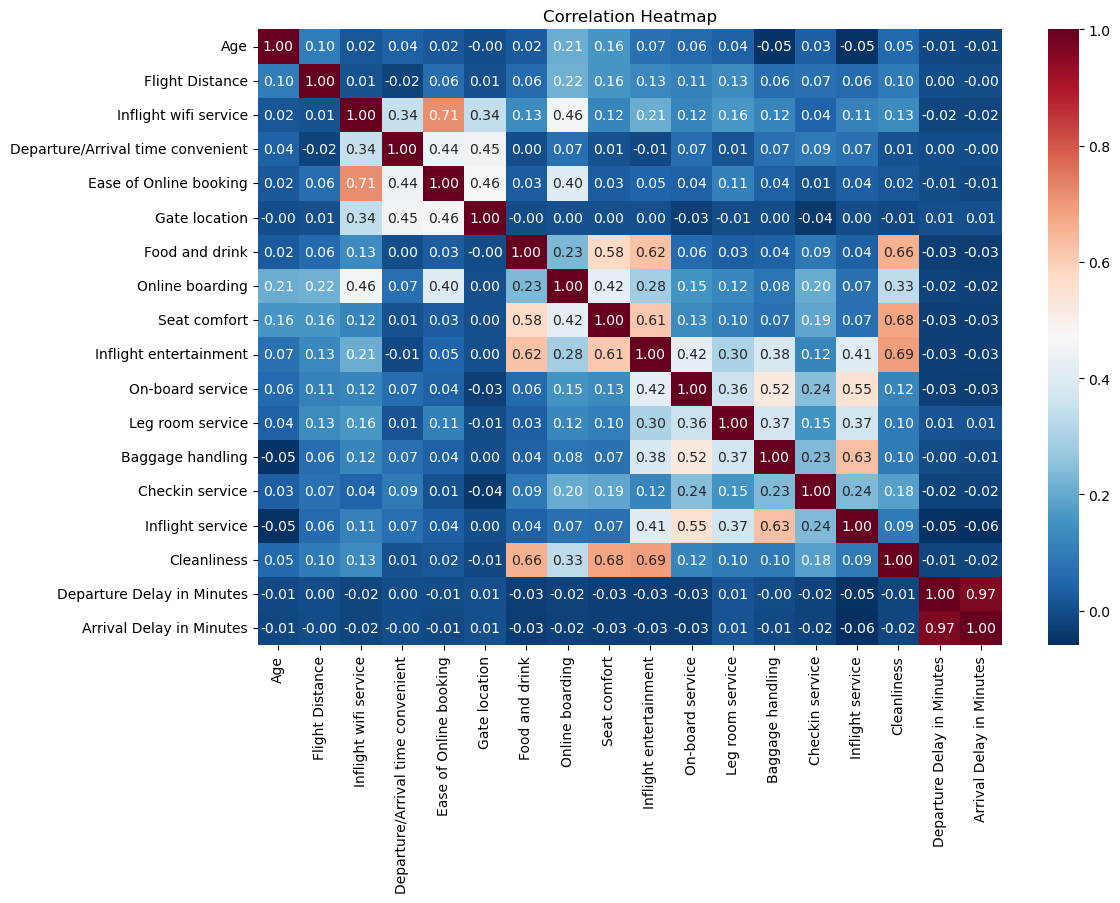

In [16]:
corr_matrix = airline_df.corr(numeric_only=True)

plt.figure(figsize = (12,8))
sns.heatmap(corr_matrix, annot = True, cmap = "RdBu_r", fmt = ".2f")
plt.title("Correlation Heatmap")

### Correlation matrix results:

#### Key observations include:
- Departure Delay and Arrival Delay exhibit a very strong positive correlation, which is expected since departure delays often propagate to arrival times.
- Most other variables show weak correlations with each other, indicating low chances of multicollinearity across the dataset.
- Service rating variables exhibit moderate correlations with each other, suggesting that passengers who rate one service highly may also rate other services positively.

Overall, the dataset does not show widespread strong correlations between most variables.

### 3.5 Outlier Detection

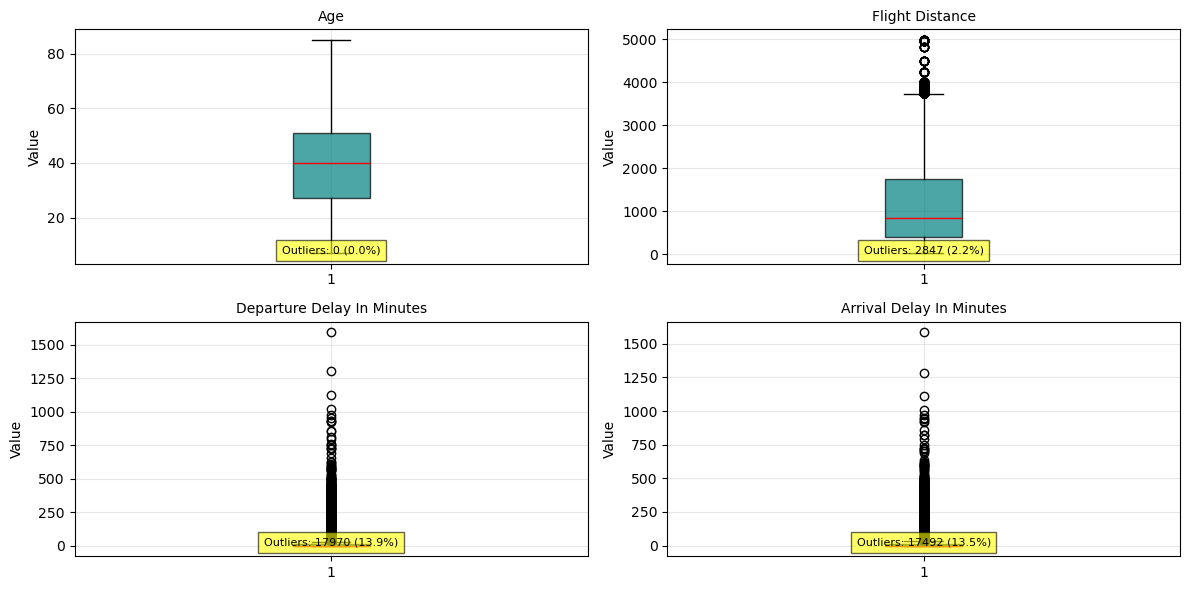

In [17]:
# Boxplots with Outlier Info 
features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize = (12, 6))

for i, feat in enumerate(features):
    if feat in airline_df.columns:
        data = airline_df[feat]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((data < lower) | (data > upper)).sum()
        pct = (outliers / len(data)) * 100

        plt.subplot(2, 2, i + 1)
        plt.boxplot(data, patch_artist = True,
                    boxprops = dict(facecolor = 'teal', alpha = 0.7),
                    medianprops = dict(color = 'red'))
        plt.title(feat.replace('_', ' ').title(), fontsize = 10)
        plt.ylabel('Value')
        plt.text(1, min(data), f'Outliers: {outliers} ({pct:.1f}%)',
                 ha = 'center', fontsize = 8, bbox = dict(facecolor = 'yellow', alpha = 0.6))
        plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Outlier detection using the IQR method reveals:

#### Age
- Very few outliers are present, indicating that age values fall within a reasonable range.

#### Flight Distance
- Some outliers appear at higher distances, representing long-haul flights, which are expected in airline datasets.

#### Departure Delay
- A large number of extreme values are observed, indicating occasional severe delays.

#### Arrival Delay
- Similar to departure delays, this variable contains many extreme delay values.

Because delays can naturally vary widely in real-world flight operations, these extreme values likely represent genuine observations rather than data entry errors. Therefore, these outliers will be retained during the data cleaning stage, as removing them could eliminate meaningful information about flight disruptions.

# 3.0 Data Preparation 

# 4.0 Data Preprocessing 

# 5.0 Modelling 

# 6.0 Evaluation & Conclusion 